In [65]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.ndimage import histogram

$$P(X = k) = \begin{cases} \frac{1}{6} & \text{if } k \in \{1, 2, 3, 4, 5, 6\} \\ 0 & \text{otherwise} \end{cases} \qquad \mathbb{E}[X] = \sum_{k=1}^{6} k \cdot P(X = k) = \frac{1 + 2 + 3 + 4 + 5 + 6}{6} = 3.5$$

Let X be the random variable of rolling a die with uniform distribution, same probability for each outcome
Buy low, sell high around the expected value (3.5)

In [66]:
rand_var = np.random.randint(1, 7, 1)  # randint is exclusive of upper bound
rand_var[0]

np.int32(3)

In [67]:
HISTORY_PRICES: list[int] = [] # no need for index ig? since they will be in order of time, but can add timestamp later if needed
HISTORY_PROFIT: list[int] = [] # same thing for this, list of ints
HISTORY_PORTFOLIO: list[dict[str, int]] = [] # same thing for this, list of dicts

In [68]:
SIMULATIONS = 1000
EXPECTED_VALUE = 3.5

PROFIT = 0

PORTFOLIO = {
    "1": 0,
    "2": 0,
    "3": 0,
    "4": 0,
    "5": 0,
    "6": 0,
}

In [69]:
for i in range(SIMULATIONS):
    rand_var = np.random.randint(1, 7, 1)
    HISTORY_PRICES.append(rand_var[0])

    if rand_var[0] == 3:
        PORTFOLIO[str(rand_var[0])] += 1

    elif rand_var[0] in {4, 5, 6}:
        if PORTFOLIO["3"] > 0:
            PROFIT += 1
            PORTFOLIO["3"] -= 1

    HISTORY_PORTFOLIO.append(PORTFOLIO.copy())  # .copy() fixes the mutable dict bug
    HISTORY_PROFIT.append(PROFIT)

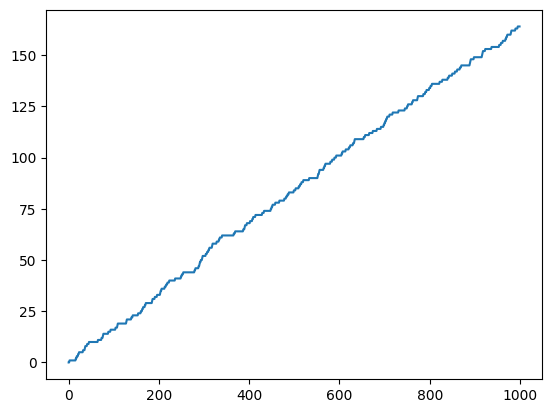

In [73]:
plt.plot(HISTORY_PROFIT)

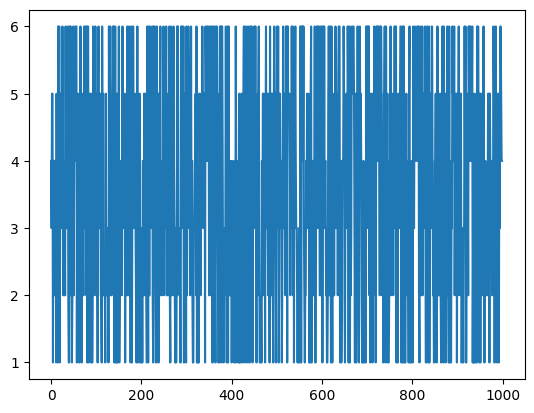

In [74]:
plt.plot(HISTORY_PRICES)

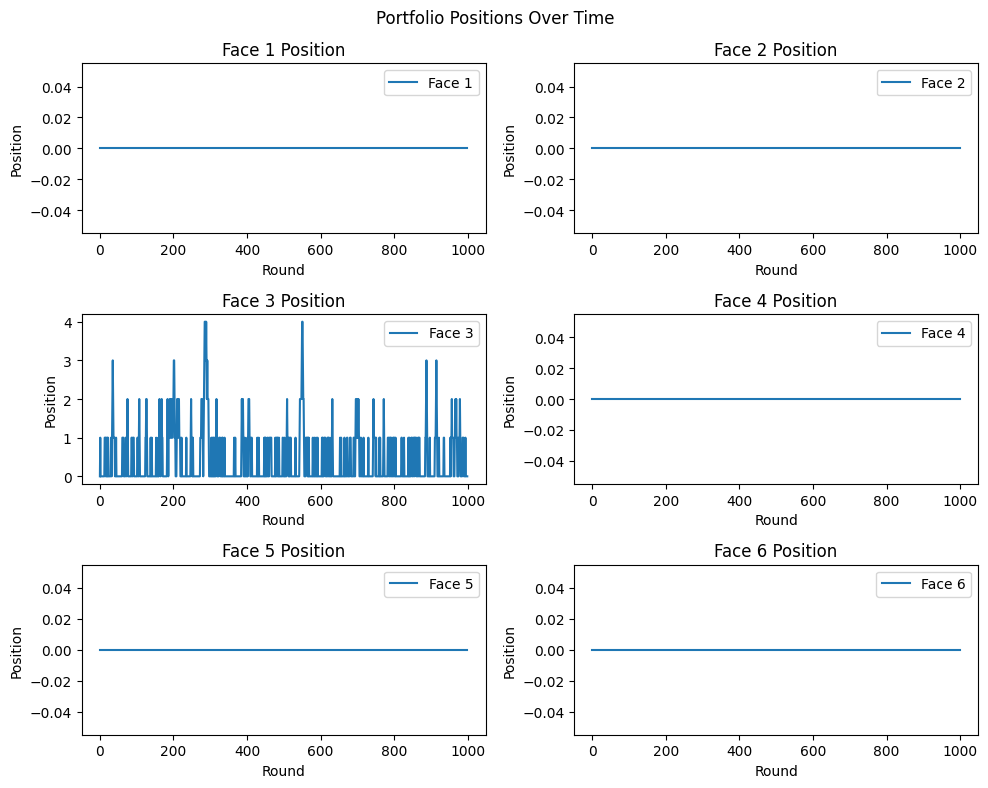

In [75]:
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for i, item in enumerate(PORTFOLIO.keys()):
    axes[i].plot([h[item] for h in HISTORY_PORTFOLIO], label=f"Face {item}")
    axes[i].set_title(f"Face {item} Position")
    axes[i].set_xlabel("Round")
    axes[i].set_ylabel("Position")
    axes[i].legend()

plt.suptitle("Portfolio Positions Over Time")
plt.tight_layout()
plt.show()